In [271]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Download an open-source dataset from Kaggle or any other platform, preferably related to your domain.The data set must contain a minimum of 100rows, include missing values and outliers,and have mixed datatypes(both numerical and categorical variables).

In [272]:
# Kaggle Link 
# https://www.kaggle.com/datasets/gauravsharma99/car-mpg

2. Load the dataset using pandas. Display basic information such as head(), info(), and describe().Identify the data types and check for missing values.

In [273]:
# Load the CSV File
data = pd.read_csv('mpg_raw.csv')

In [274]:
data.shape

(398, 9)

Data has 398 Rows and 9 Columns

In [275]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [276]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [277]:
data.describe(exclude='str')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [278]:
data.describe(include='str')

,origin,name
count,398,398
unique,3,305
top,usa,ford pinto
freq,249,6


In [279]:
data.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

In [280]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Feature Horsepower Column has 6 missing values

3. Apply one numerical and one categorical imputation method. Justify your choice of imputation techniques.

In [281]:
# drop the car name column as it is not usefull for creating a ML model
data = data.drop('name', axis=1)

In [282]:
# replace the missing values in 'horsepower' with mean or avg value of 'horsepower' 
data['horsepower'] = data['horsepower'].fillna(data['horsepower'].mean(), inplace=True)

In [283]:
data.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [284]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


4. Handling outliers using either the IQR method or the Z-score method. Explain whether the detected anomalies are errors or valid observations

In [285]:
data.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
dtype: object

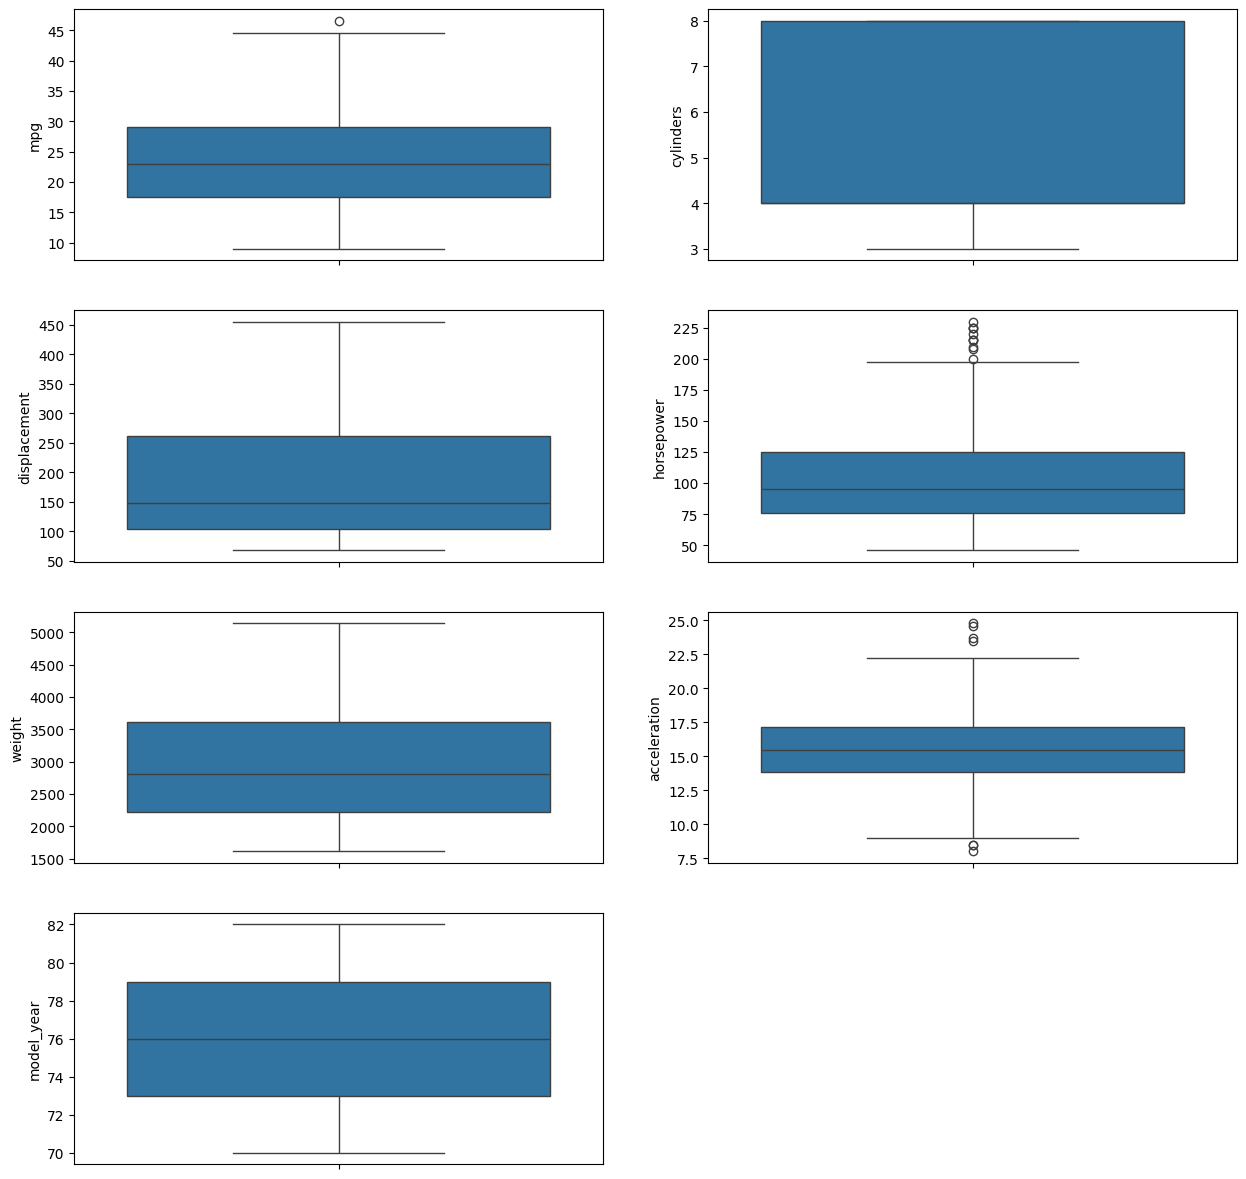

In [286]:
plt.figure(figsize=(15,15))
i = 1
for n in list(data.select_dtypes(exclude='str')):
    plt.subplot(4,2,i)
    sns.boxplot(data[n])
    i = i + 1
plt.show()

We can see from the above plot that accleration and horsepower has few outliers

These outliers are valid observations and not anomalies

In [287]:
# Using IQR method to remove outliers
num_col = data.select_dtypes(exclude='str')

q1 = num_col.quantile(0.25)
q3 = num_col.quantile(0.75)
iqr = q3-q1

u_q = q3+(1.5*iqr)
l_q = q1-(1.5*iqr)

data_treated = data[~((num_col < l_q) | (num_col > u_q)).any(axis=1)]

print("Before Treatment : ", data.shape)
print("After Treatment : ", data_treated.shape)

Before Treatment :  (398, 8)
After Treatment :  (380, 8)


5. Perform atleast two transformations, such as scaling, log transformation, or encoding. Explain why these transformations were necessary

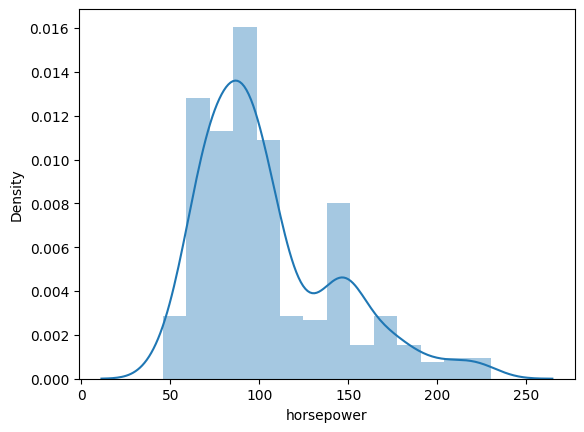

Skew :  1.0955524807071189


In [288]:
sns.distplot(data['horsepower'])
plt.show()
print("Skew : ",data['horsepower'].skew() )

In [289]:
# Log Transformation helps in reducing the skewness of the feature
data['horsepower_log'] = np.log(data['horsepower'])

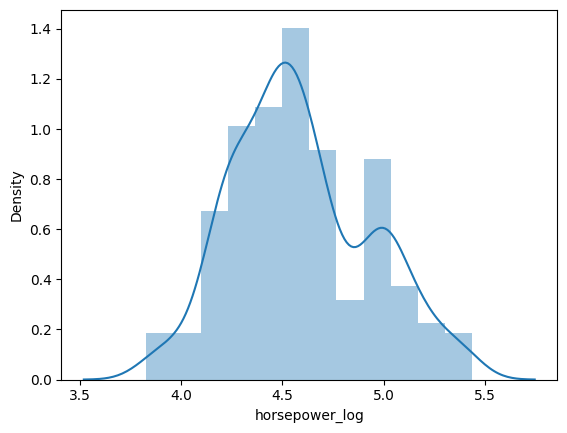

Skew :  0.36463902913114593


In [290]:
sns.distplot(data['horsepower_log'])
plt.show()
print("Skew : ",data['horsepower_log'].skew() )

In [291]:
# Convert categorical variable into numerical variables
data = pd.get_dummies(data, columns=['origin'])

In [292]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,horsepower_log,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,4.867534,False,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,5.105945,False,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,5.010635,False,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,5.010635,False,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,4.941642,False,False,True


6. Create atleast two new features from existing columns. Explain how the engineered features improve the analysis or modeling process.

power_to_weight ratio captures performance demand more directly than using horsepower and weight separately. Cars with high power relative to mass typically consume more fuel

In [293]:
data['power_to_weight'] = 1000*data['horsepower'] / data['weight']

disp_per_cyl approximates cylinder bore/stroke size and correlates with combustion characteristics and efficiency

In [294]:
data['disp_per_cyl'] = data['displacement'] / data['cylinders']

In [295]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,horsepower_log,origin_europe,origin_japan,origin_usa,power_to_weight,disp_per_cyl
0,18.0,8,307.0,130.0,3504,12.0,70,4.867534,False,False,True,37.100457,38.375
1,15.0,8,350.0,165.0,3693,11.5,70,5.105945,False,False,True,44.679123,43.750
2,18.0,8,318.0,150.0,3436,11.0,70,5.010635,False,False,True,43.655413,39.750
3,16.0,8,304.0,150.0,3433,12.0,70,5.010635,False,False,True,43.693562,38.000
4,17.0,8,302.0,140.0,3449,10.5,70,4.941642,False,False,True,40.591476,37.750
